In [16]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

### Channel labels

In [2]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [3]:
data_dir = 'C:/user-link/Documents/data/preprocessed_data/'
out_path = 'C:/user-link/Documents/data/derivatives/'
scores_path = 'C:/user-link/Documents/data/LOR_scores'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [4]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [5]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

### Select bursts corresponding to C3/C4 and all STN contacts

In [6]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

### Plot the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN 

In [7]:
burst_times = all_bursts['waveform_times'] * 1000 

In [8]:
on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [9]:
def reject_outliers(X, m=3):
    """
    https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')
    mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    return [d for d in X if lower_bound <= d <= upper_bound]

In [10]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [26]:
where = c_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    
    scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the median and IQR values
    # scaler = StandardScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the median and IQR values
    scaled_waveforms[subj_idx, :] = scaler.transform(all_bursts['waveform'][subj_idx])  # .transform() does the maths.

    # median, mad = scaler_fit(all_bursts['waveform'][subj_idx & where])
    # scaled_waveforms[subj_idx, :] = scaler_transform(all_bursts['waveform'][subj_idx], median, mad)



In [27]:
# Group-level cross-validation: split subjects into train/test groups
n_bins = 4              # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]   # List of gcPC columns to consider
# m=2

subjects = np.array(subjects)
n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)


fold_scores = []
train_fold_scores = []

for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
    train_subs = subjects[train_s_idx]
    test_subs = subjects[test_s_idx]

    # select bursts from training subjects (cortex channels only)
    train_bursts_idx = np.isin(all_bursts['subject'], train_subs) & where
    train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
    train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')

    # Fit PCA on training subjects' bursts
    pca_model = PCA(n_components=4, random_state=6)

    pca_model.fit(scaled_waveforms[train_bursts_off_idx, :])
    all_scores = scaled_waveforms @ pca_model.components_.T

    X_train, X_test, y_train, y_test = [], [], [], []

    # compute percentile bin limits using training bursts only
    pc_bin_lims = np.zeros((len(cols), n_bins + 1))
    for i, col in enumerate(cols):
        pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

    print(f'Fold {fold_idx}: Training on subjects {train_subs}, Testing on subjects {test_subs}')

    ntrials_train = []
    for i in range(len(train_subs)):
        train_sub = train_subs[i]
        # Build trial-level features across all cortex trials
        trials = np.unique(all_bursts['trial'][(all_bursts['subject'] == train_sub)])
        ntrials_train.append(int(np.max(trials)))

        for trial in trials:
            burst_idx = where & (all_bursts['trial'] == trial) & (all_bursts['subject'] == train_sub)
            # temp_idx = where & (all_bursts['trial'] == trial)
            # isin_mask = np.zeros(len(all_bursts['peak_amp_base']), dtype=bool)
            # isin_mask[temp_idx] = np.isin(all_bursts['peak_amp_base'][temp_idx], reject_outliers(all_bursts['peak_amp_base'][temp_idx], m=m))
            # burst_idx = temp_idx & (all_bursts['subject'] == train_sub) & isin_mask
            label = np.unique(all_bursts['med'][burst_idx])[0]
            
            row = []
            for i, col in enumerate(cols):
                for bin in range(n_bins):
                    lower = pc_bin_lims[i, bin]
                    higher = pc_bin_lims[i, bin+1]
                    # count = np.sum((all_scores[burst_idx, col] >= lower) & (all_scores[burst_idx, col] < higher)[0])
                    count = np.sum((all_scores[burst_idx, col] >= lower) & (all_scores[burst_idx, col] < higher))
                    row.append(int(count))
            X_train.append(row)
            y_train.append(0 if label == 'OFF' else 1)

    # Replicate row once per test subject
    ntrials_test = []
    for i in range(len(test_subs)):
        test_sub = test_subs[i]
        trials = np.unique(all_bursts['trial'][(all_bursts['subject'] == test_sub)])
        ntrials_test.append(int(np.max(trials)))
        for trial in trials:
            burst_idx = where & (all_bursts['trial'] == trial) & (all_bursts['subject'] == test_sub)
            # temp_idx = where & (all_bursts['trial'] == trial)
            # isin_mask = np.zeros(len(all_bursts['peak_amp_base']), dtype=bool)
            # isin_mask[temp_idx] = np.isin(all_bursts['peak_amp_base'][temp_idx], reject_outliers(all_bursts['peak_amp_base'][temp_idx], m=m))
            # burst_idx = temp_idx & (all_bursts['subject'] == test_sub) & isin_mask
            label = np.unique(all_bursts['med'][burst_idx])[0]

            row = []
            for i, col in enumerate(cols):
                for bin in range(n_bins):
                    lower = pc_bin_lims[i, bin]
                    higher = pc_bin_lims[i, bin+1]
                    # count = np.sum((all_scores[burst_idx, col] >= lower) & (all_scores[burst_idx, col] < higher)[0])
                    count = np.sum((all_scores[burst_idx, col] >= lower) & (all_scores[burst_idx, col] < higher))
                    row.append(int(count))
            X_test.append(row)
            y_test.append(0 if label == 'OFF' else 1)

    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    model = LOR(max_iter=1000)
    model = model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    train_score = 1 - np.sqrt(np.mean((y_train - y_train_pred) ** 2))

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # model_sm = sm.Logit(y_train, sm.add_constant(X_train))
    # results = model_sm.fit()  # disp=0 to suppress output
    # # predictions = model_sm.get_prediction(X_test)
    # summary = results.summary()
    # # print(summary)

    intercept = model.intercept_
    coefs = model.coef_
    print(f'Fold {fold_idx} Logistic Regression Coefficients:')
    for i, col in enumerate(cols):
        for bin in range(n_bins):
            print(f'  PC{col} Bin {bin}:\tCoef =\t {coefs[0][i*n_bins + bin]:.4f}')

    score = 1 - np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f'Fold {fold_idx}: Score = {score:.3f}, Training set score = {train_score:.3f}\n')
    # print('  train_subs:', train_subs)
    # print('  test_subs:', test_subs)
    # print(f'  X_train shape: {X_train.shape}')
    # print(f'  X_test shape: {X_test.shape}\n')
    fold_scores.append(score)
    train_fold_scores.append(train_score)

print(f'Group-level CV: Mean Score = {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}, Train Mean Score = {np.mean(train_fold_scores):.3f}  ± {np.std(train_fold_scores):.3f}')

Fold 0: Training on subjects ['s02' 's04' 's05' 's06' 's07' 's08' 's10' 's15' 's17' 's18'], Testing on subjects ['s16']
Fold 0 Logistic Regression Coefficients:
  PC0 Bin 0:	Coef =	 0.1802
  PC0 Bin 1:	Coef =	 0.0989
  PC0 Bin 2:	Coef =	 0.0743
  PC0 Bin 3:	Coef =	 0.0348
  PC1 Bin 0:	Coef =	 0.0317
  PC1 Bin 1:	Coef =	 -0.1421
  PC1 Bin 2:	Coef =	 -0.1382
  PC1 Bin 3:	Coef =	 -0.0628
  PC-2 Bin 0:	Coef =	 -0.0875
  PC-2 Bin 1:	Coef =	 -0.1407
  PC-2 Bin 2:	Coef =	 -0.0479
  PC-2 Bin 3:	Coef =	 -0.0135
  PC-1 Bin 0:	Coef =	 -0.0465
  PC-1 Bin 1:	Coef =	 -0.1985
  PC-1 Bin 2:	Coef =	 -0.1857
  PC-1 Bin 3:	Coef =	 0.1103
Fold 0: Score = 0.558, Training set score = 0.456

Fold 1: Training on subjects ['s02' 's05' 's06' 's07' 's08' 's10' 's15' 's16' 's17' 's18'], Testing on subjects ['s04']
Fold 1 Logistic Regression Coefficients:
  PC0 Bin 0:	Coef =	 0.0400
  PC0 Bin 1:	Coef =	 -0.0844
  PC0 Bin 2:	Coef =	 0.0134
  PC0 Bin 3:	Coef =	 -0.1091
  PC1 Bin 0:	Coef =	 0.0905
  PC1 Bin 1:	Coef =

In [ ]:
burst_idx_1 = where & (all_bursts['trial'] == trial) & (all_bursts['subject'] == test_sub)
subject_data = all_bursts['peak_amp_base'][burst_idx_1]
good_values = reject_outliers(subject_data, m=1.5)
is_good_trial = np.isin(subject_data, good_values)
burst_idx_2 = burst_idx_1.copy()
burst_idx_2[burst_idx_1] = is_good_trial

n_before = np.sum(burst_idx_1)
n_after = np.sum(burst_idx_2)

if n_before == n_after:
    print("TRUE")

In [ ]:
subjects_coefs = np.load('subjects_coefs.npy', allow_pickle=True).item()
print(subjects_coefs)

{'s02': [array([[-0.13315128,  0.13694917,  0.13917363, -0.13212232, -0.123028  ,
         0.12368707,  0.1365388 , -0.12605546,  0.03925472, -0.02293325,
        -0.03410107,  0.0275816 ,  0.04032353, -0.04212433, -0.05107327,
         0.06302574]])], 's04': [array([[-0.08119167,  0.08049778,  0.0844475 , -0.0812062 , -0.07940293,
         0.08213897,  0.08077693, -0.0809004 ,  0.01678998, -0.01676457,
        -0.01478089,  0.01682222,  0.01824492, -0.02025167, -0.01747933,
         0.02157136]])], 's05': [array([[-0.25574654,  0.14344139,  0.13509284, -0.1981799 , -0.18755294,
         0.09392577,  0.11803596, -0.2020079 ,  0.04969809, -0.18224817,
        -0.09519765,  0.04817204,  0.0648902 , -0.13864082, -0.11934687,
         0.01479957]])], 's06': [array([[-0.06308074,  0.04685845,  0.05378974, -0.03319823, -0.02423155,
         0.03335701,  0.0297858 , -0.03495927,  0.08098686, -0.08895852,
        -0.08414125,  0.09490699,  0.14801851, -0.14432734, -0.15258758,
         0.15198

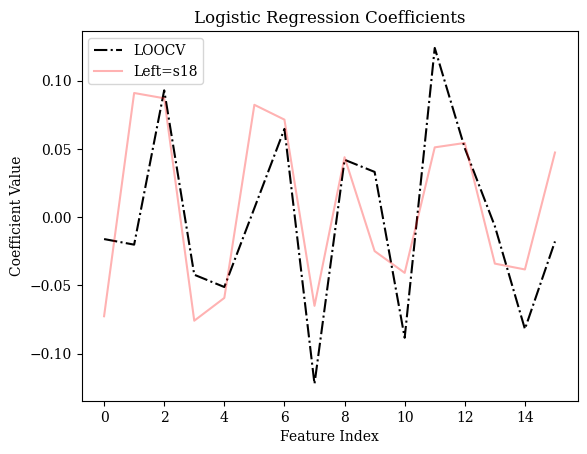

In [ ]:
plt.plot(coefs.flatten(),  linestyle='-.', color='black', label='LOOCV')  # linestyle='-', 
plt.plot(subjects_coefs['s18'][0].flatten(), color='red', alpha=0.3, label='Left=s18')
plt.legend(loc="upper left")
plt.title('Logistic Regression Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.show()

(Text(0, 0.5, 'Burst count'),
 Text(0.5, 0, 'Features'),
 Text(0.5, 1.0, 'Group-level - f(Features) = Burst Count'))

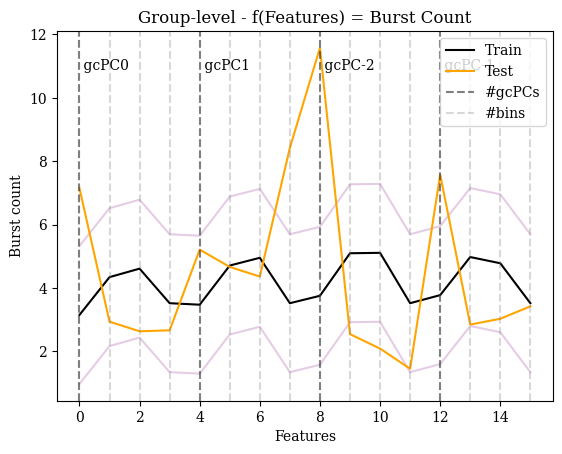

In [ ]:
sem_X_train = np.sqrt(np.std(X_train))
mean_X_train = np.mean(X_train, axis=0)
upper = mean_X_train + sem_X_train
lower = mean_X_train - sem_X_train

y_lim = max(int(np.max(mean_X_train)), int(np.max(np.mean(X_test, axis=0))))

plt.plot(mean_X_train, color='black', label='Train')
plt.plot(upper, color='purple', alpha=0.2)
plt.plot(lower, color='purple', alpha=0.2)
plt.plot(np.mean(X_test, axis=0), color='orange', label='Test')

for j, col in zip(range(0, len(np.mean(X_test, axis=0)), 4), cols):
    plt.axvline(j, color='black', linestyle='--', alpha=0.5, label="#gcPCs" if j == 0 else None)
    plt.text(j, y_lim-(y_lim/100), f" gcPC{col}")

for j in range(0, len(np.mean(X_test, axis=0))):
    plt.axvline(j, color='gray', linestyle='--', alpha=0.3, label="#bins" if j == 0 else None)

plt.legend()
plt.ylabel("Burst count"), plt.xlabel("Features"), plt.title("Group-level - f(Features) = Burst Count")

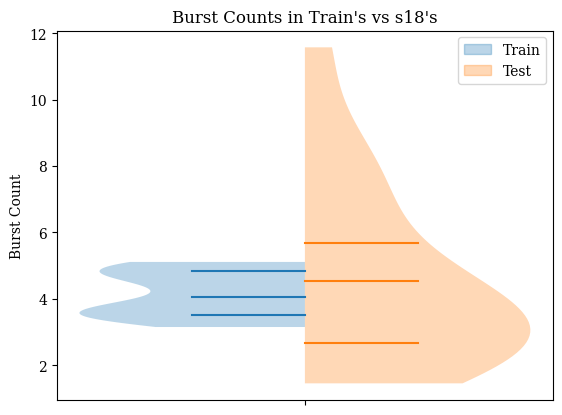

In [ ]:
violin_labels = []
def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    violin_labels.append((mpatches.Patch(color=color), label))

add_label(plt.violinplot(mean_X_train, positions=[1], widths=0.2, showmedians=True, showextrema=False, side='low', quantiles=[0.25, 0.75]), label="Train")
add_label(plt.violinplot(np.mean(X_test, axis=0), positions=[1], widths=0.2, showmeans=True, showextrema=False, side='high', quantiles=[0.25, 0.75]), label="Test")
plt.xticks([1], [''])
plt.title("Burst Counts in Train's vs s18's")
plt.ylabel('Burst Count')
plt.legend(*zip(*violin_labels))
plt.show()


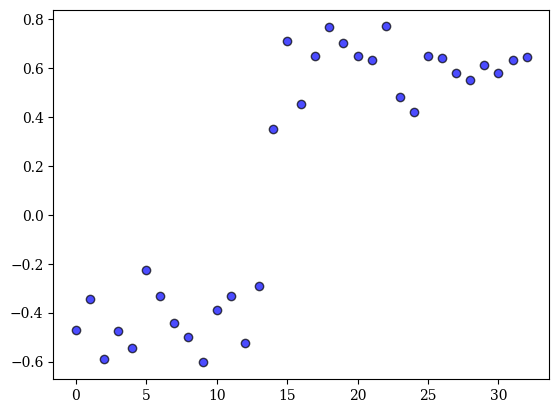

In [ ]:
# residuals = []
# for i, (y_test, ProbOfYIs1) in enumerate(zip(y_test, y_prob)):
#     residual = y_test - ProbOfYIs1[:, 1]
#     residuals.append(residual)

residuals = y_test - y_prob[:, 1]

plt.scatter(range(0, len(residuals)), residuals, marker='o', color="blue", alpha=0.7, edgecolor='k')

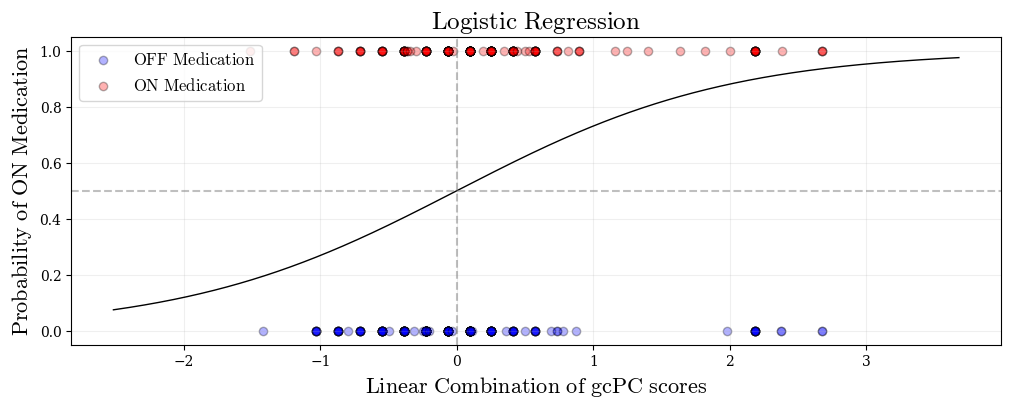

In [ ]:
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])
z = intercept + (X @ coefs.ravel())
z_range = np.linspace(np.min(z) - 1, np.max(z) + 1, 1000)
p_range = 1 / (1 + np.exp(-z_range))
plt.figure(figsize=(12, 4))
plt.plot(z_range, p_range, color='black', linewidth=1)  # , label=r"$\mathrm{Logistic\ Regression\ Fit}$"
plt.scatter(z[y==0], y[y==0], color='blue', alpha=0.3, label=r"$\mathrm{OFF\ Medication}$", edgecolor='k')
plt.scatter(z[y==1], y[y==1], color='red', alpha=0.3, label=r"$\mathrm{ON\ Medication}$", edgecolor='k')
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='grey', linestyle='--', alpha=0.5)
plt.title(r"$\mathrm{Logistic\ Regression}$", fontsize=18)
plt.xlabel(r"$\mathrm{Linear\ Combination\ of\ gcPC\ scores}$", fontsize=16)
plt.ylabel(r"$\mathrm{Probability\ of\ ON\ Medication}$", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.show()

In [ ]:
waveform_test = scaled_waveforms[(all_bursts["subject"] == "s18")]
waveform_train = []

for sub in train_subs:
    waveform_sub = []
    waveform_sub.append(scaled_waveforms[(all_bursts["subject"] == sub)])
    waveform_train = np.vstack(waveform_sub)
    waveform_train = np.mean(waveform_train, axis=1)

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\Loquet Jeremie\AppData\Local\Temp\ipykernel_15224\3420013146.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[col, q].legend()


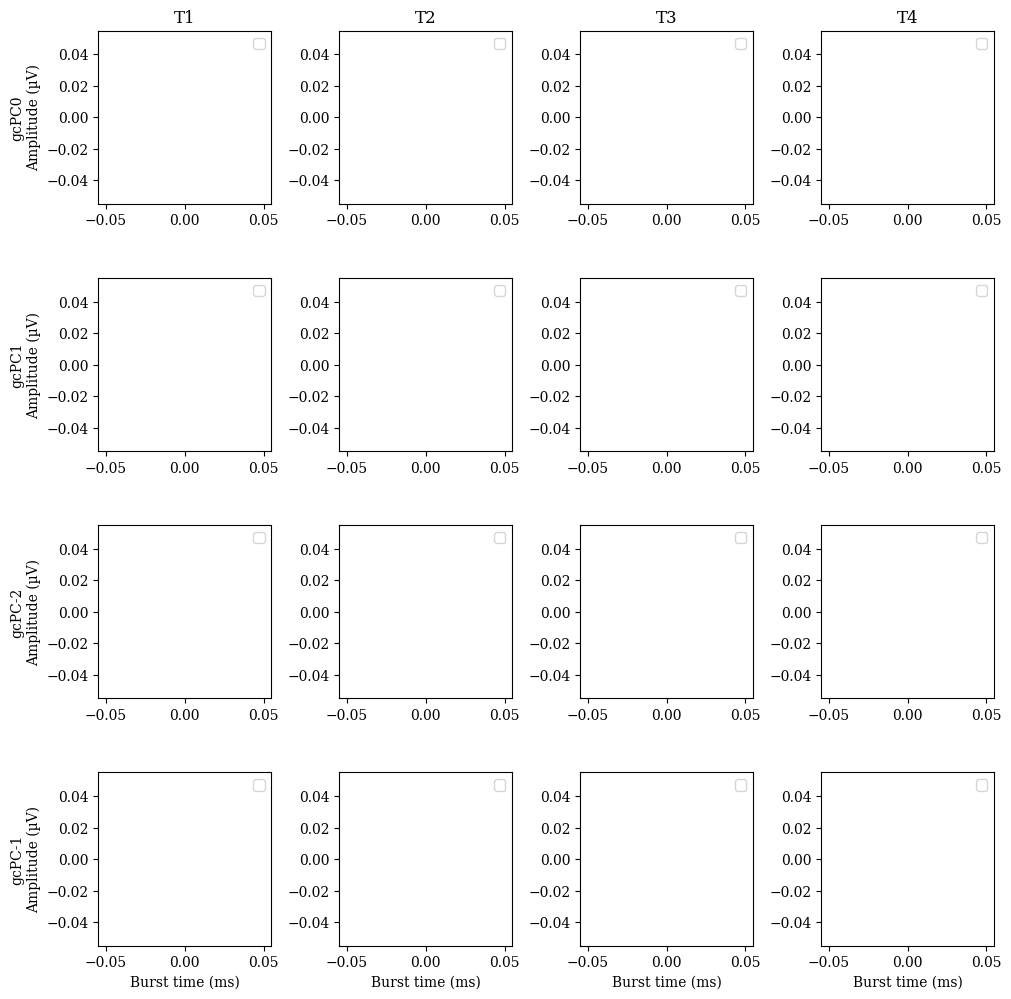

In [ ]:
on_b_idx = where & on_idx
off_b_idx = where & off_idx

n_q = 3
col_r = plt.cm.cool(np.linspace(0, 1, num=n_bins))
step = 100 / n_bins

q_bins = np.percentile(all_scores[where, 0], np.arange(0, 100+step, step))
# plot loadings

# Create a figure with constrained layout
fig, ax = plt.subplots(len(cols), n_bins, figsize=(10, 10), constrained_layout=True)

def make_square(ax):
    ax.set_box_aspect(1)  # This ensures the subplot is a square (1:1 height:width)

n_q = 3
col_r = plt.cm.cool(np.linspace(0, 1, num=n_bins))
rev_col_r = col_r[::-1]
step = 100 / n_bins

q_bins = np.percentile(all_scores[where, 0], np.arange(0, 100+step, step))

pc_bin_lims = np.zeros((len(cols), n_bins + 1))
for i, col in enumerate(cols):
    pc_bin_lims[i, :] = np.percentile(all_scores[where, col], np.arange(0, 100+step, step))



gc_pca_scores=[]
for sub in subjects:
    sub_burst_on_idx = (all_bursts['subject'] == sub) & on_idx
    sub_burst_off_idx = (all_bursts['subject'] == sub) & off_idx
    sub_scaled_on_bursts = scaled_waveforms[sub_burst_on_idx,:]
    sub_scaled_off_bursts = scaled_waveforms[sub_burst_off_idx,:]
    sub_gcpca_model = gcPCA(method='v4', normalize_flag=False)
    sub_gcpca_model.fit_transform(sub_scaled_on_bursts, sub_scaled_off_bursts)
    all_scores = scaled_waveforms @ gcpca_model.loadings_
    
for q in range(n_bins):
    for col in cols:
        lims = (all_scores[:, col] >= q_bins[q]) & (all_scores[:, col] <= q_bins[q+1])
        # for sub in train_subs:
        #     q_idx_train = where & lims & (all_bursts['subject'] == sub)
        #     q_waveform_train = np.mean(all_bursts['waveform'][q_idx_train, :], axis=0)

        # for sub in test_subs:
        #     q_idx_test = where & lims & (all_bursts['subject'] == sub)
        #     q_waveform_test = np.mean(all_bursts['waveform'][q_idx_test, :], axis=0)

        for sub in subject:
            q_idx = where & lims & (all_bursts['subject'] == sub)
            q_waveform = np.mean(all_bursts['waveform'][q_idx, :], axis=0)

        ax[col, q].plot(burst_times, q_waveform, color=col_r[q, :])  # , label='Train')
        # ax[col, q].plot(burst_times, q_waveform_test, color=rev_col_r[q, :], label='Test')  # color=,"black"
        ax[len(cols)-1, q].set_xlabel('Burst time (ms)')
        ax[col, 0].set_ylabel(f'gcPC{col}\nAmplitude (µV)')
        ax[col, q].legend()
        ax[0, q].set_title(f"T{q+1}")
        make_square(ax[col, q])